# mcl-PHAs / DTS data / Storage modulus Predictor

**Author:** Lab of Farm Structures
**Date:** 2026-05

## Import libraries

In [128]:
import pandas as pd
import kennard_stone as ks
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import math
import shap
from prince import FAMD
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import seaborn as sns
from jaqpotpy import Jaqpot
from jaqpotpy.datasets import JaqpotTabularDataset
from jaqpotpy.models.sklearn import SklearnModel
from jaqpotpy.doa import Leverage, BoundingBox, MeanVar
from jaqpotpy.models.xgboost import XGBoostModel
from sklearn.model_selection import GroupShuffleSplit
from scipy.stats import pearsonr

## Load data

In [74]:
model_stor = 'rheological_DTS_mcl_storage_LM'

df_stor = pd.read_csv(f'{model_stor}.csv')
df_stor.head()

,study_id,instance,3hb_ratio_mol,3ho_ratio_mol,3hdd_ratio_mol,3httd_ratio_mol,unsaturated_monomer_ratio_mol,uknown_monomer_ratio_mol,additive1_percentage_wt,additive1_type,final_pha_percentage_wt,frequency_experimental_fixed_hz,temperature,storage_modulus,log_storage_modulus
0,3,1,0.0,86.0,0,0,0,14,0.0,no_additive,100.0,1.0,-123.0,1909.853259,3.281
1,3,1,0.0,86.0,0,0,0,14,0.0,no_additive,100.0,1.0,-123.0,1435.489433,3.157
2,3,1,0.0,86.0,0,0,0,14,0.0,no_additive,100.0,1.0,-115.0,1782.378767,3.251
3,3,1,0.0,86.0,0,0,0,14,0.0,no_additive,100.0,1.0,-115.0,1402.813705,3.147
4,3,1,0.0,86.0,0,0,0,14,0.0,no_additive,100.0,1.0,-105.0,1737.800829,3.240


In [75]:
df_stor.columns

Index(['study_id', 'instance', '3hb_ratio_mol', '3ho_ratio_mol',
       '3hdd_ratio_mol', '3httd_ratio_mol', 'unsaturated_monomer_ratio_mol',
       'uknown_monomer_ratio_mol', 'additive1_percentage_wt', 'additive1_type',
       'final_pha_percentage_wt', 'frequency_experimental_fixed_hz',
       'temperature', 'storage_modulus', 'log_storage_modulus'],
      dtype='object')

## Select Features and Target

In [76]:
features = [
 'study_id', 'instance', '3hb_ratio_mol', '3ho_ratio_mol',
       '3hdd_ratio_mol', '3httd_ratio_mol', 'unsaturated_monomer_ratio_mol',
       'uknown_monomer_ratio_mol', 'additive1_percentage_wt',
       'final_pha_percentage_wt', 'frequency_experimental_fixed_hz', 'additive1_type',
       'temperature'
]

target = 'log_storage_modulus'

measure_unit = 'log_MPa'

In [77]:
# Create DataFrame
df_new = df_stor[features + [target]]

# Drop rows with N/A value
mask = (
    df_new[target].notna() &
    df_new[features].notna().all(axis=1)
)

# Create final dataset
df_final = df_new.loc[mask, features + [target]]
df_final.columns = df_final.columns.str.replace(' ', '_', regex=False)

# Check the DataFrame
df_final.tail()

,study_id,instance,3hb_ratio_mol,3ho_ratio_mol,3hdd_ratio_mol,3httd_ratio_mol,unsaturated_monomer_ratio_mol,uknown_monomer_ratio_mol,additive1_percentage_wt,final_pha_percentage_wt,frequency_experimental_fixed_hz,additive1_type,temperature,log_storage_modulus
241,11,1,1.0,25.0,7,2,49,0,0.0,100.0,1.6,no_additive,25.0,3.118727
242,11,1,1.0,25.0,7,2,49,0,0.0,100.0,1.6,no_additive,35.0,2.769890
243,11,1,1.0,25.0,7,2,49,0,0.0,100.0,1.6,no_additive,45.0,2.072215
244,11,1,1.0,25.0,7,2,49,0,0.0,100.0,1.6,no_additive,55.0,1.396573
245,11,1,1.0,25.0,7,2,49,0,0.0,100.0,1.6,no_additive,65.0,1.209302


In [78]:
df_final.shape

(246, 14)

In [79]:
# numerical columns
numerical_cols_lst = df_final.select_dtypes(include=[np.number]).columns.tolist()
# categorical columns 
categorical_cols_lst = df_final.select_dtypes(include=['object', 'category']).columns.tolist()

## Plot feature distribution

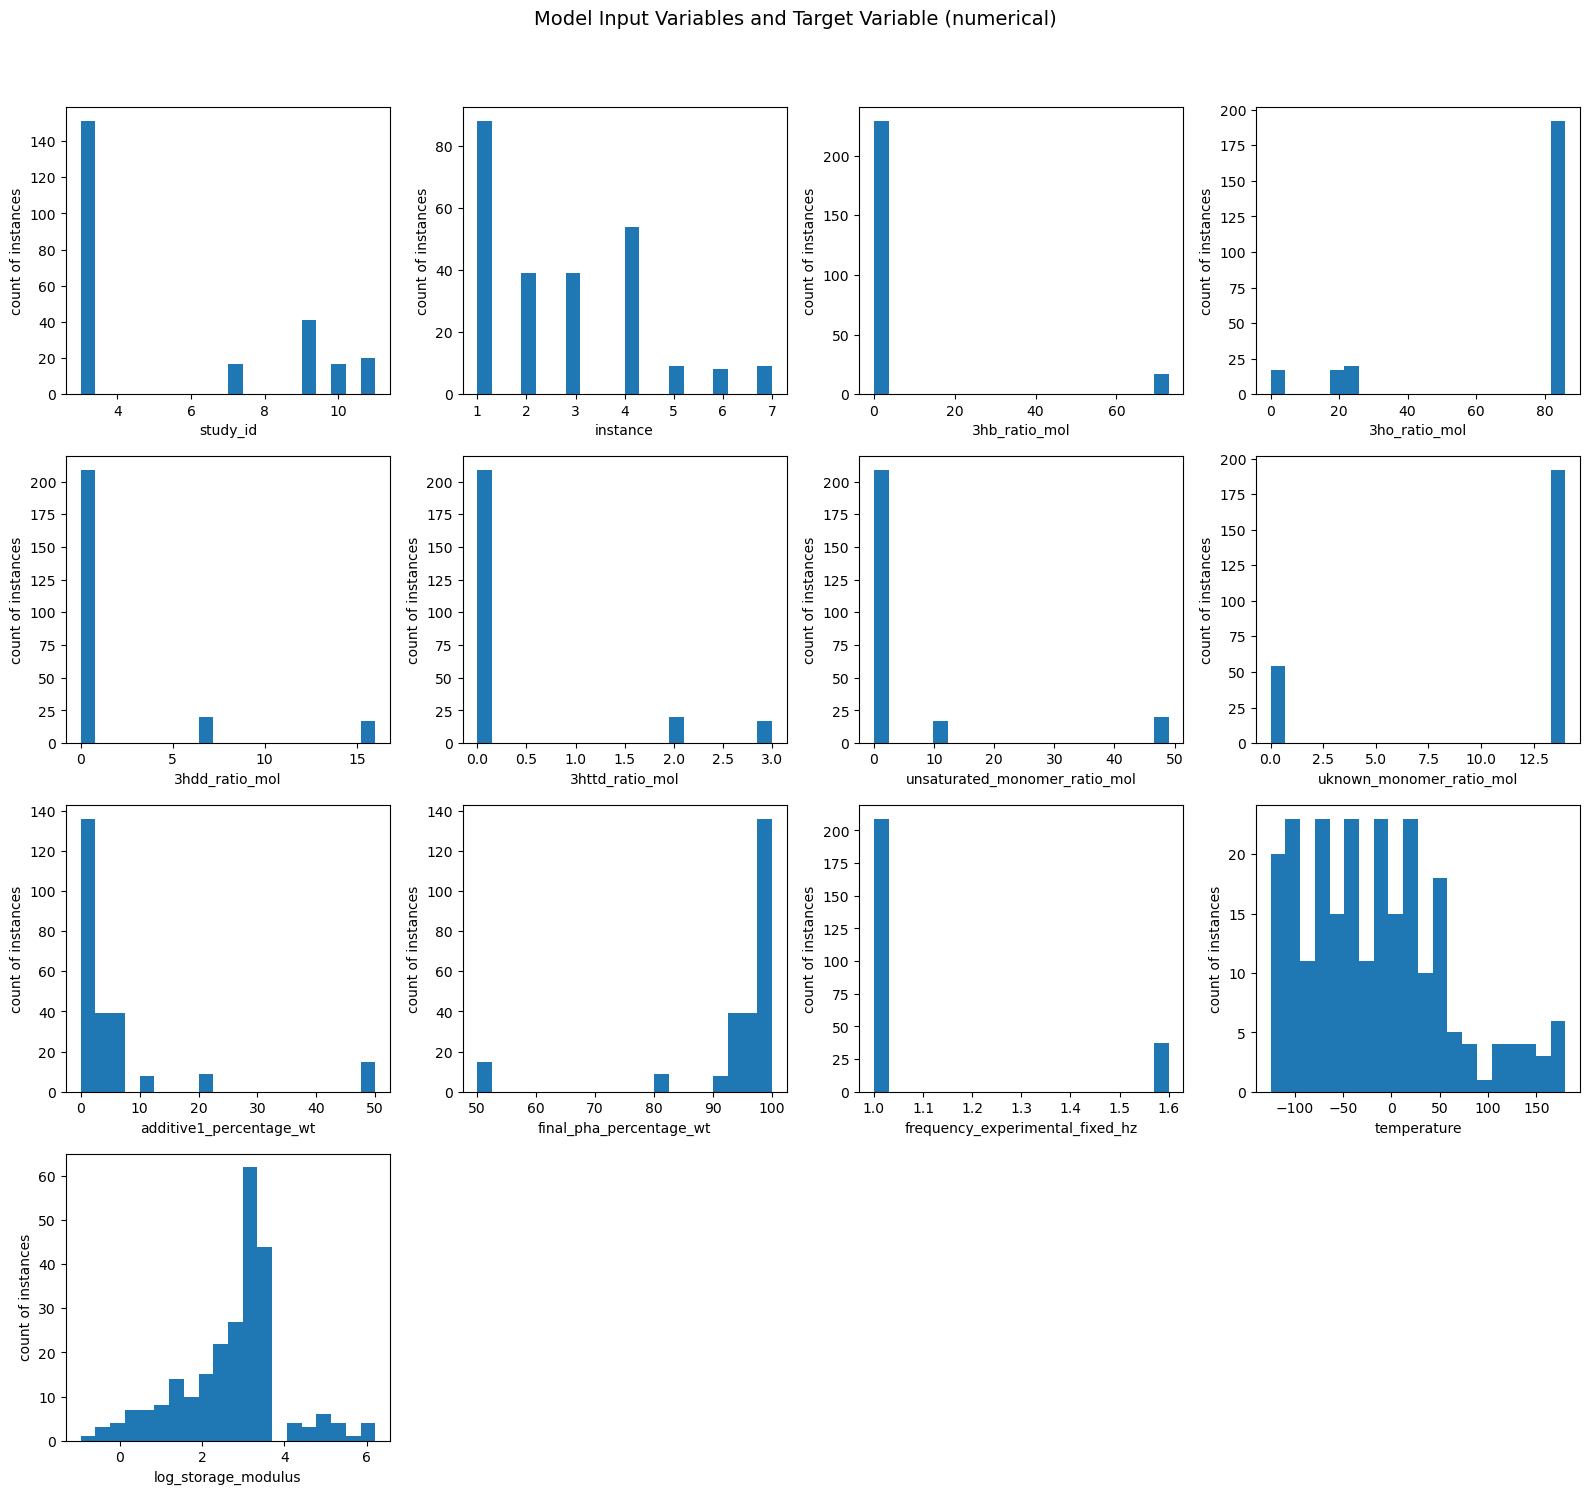

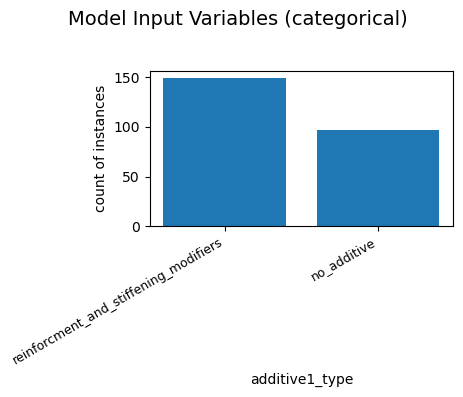

In [80]:
def plot_feature_distributions(
    df: pd.DataFrame,
    numerical_cols,
    categorical_cols,
    title_numeric="Model Input Variables and Target Variable (numerical)",
    title_categorical="Model Input Variables (categorical)",
    bins=20,
    max_cols_per_row=4,
    top_k_categories=20,   # cap bars for very high-cardinality cats
):
    # ---------- helper to grid-plot ----------
    def _grid_dims(n, max_cols):
        cols = min(max_cols, max(1, n))
        rows = int(math.ceil(n / cols))
        return rows, cols

    # ---------- NUMERICAL ----------
    if len(numerical_cols) > 0:
        n = len(numerical_cols)
        rows, cols = _grid_dims(n, max_cols_per_row)
        fig, axes = plt.subplots(rows, cols, figsize=(4.0*cols, 3.8*rows))
        axes = np.atleast_2d(axes)
        fig.suptitle(title_numeric, fontsize=14, y=0.98)

        for i, col in enumerate(numerical_cols):
            r, c = divmod(i, cols)
            ax = axes[r, c]
            x = df[col].dropna().values
            ax.hist(x, bins=bins)
            #ax.set_title(str(col), fontsize=10)
            ax.set_ylabel("count of instances")
            ax.set_xlabel(str(col))
            ax.grid(False)

        # hide any empty axes
        for j in range(n, rows*cols):
            r, c = divmod(j, cols)
            axes[r, c].axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    # ---------- CATEGORICAL ----------
    if len(categorical_cols) > 0:
        n = len(categorical_cols)
        rows, cols = _grid_dims(n, max_cols_per_row)
        fig, axes = plt.subplots(rows, cols, figsize=(4.6*cols, 4.0*rows))
        axes = np.atleast_2d(axes)
        fig.suptitle(title_categorical, fontsize=14, y=0.98)

        for i, col in enumerate(categorical_cols):
            r, c = divmod(i, cols)
            ax = axes[r, c]
            vc = (df[col].astype(str).replace("nan", np.nan)
                                 .value_counts(dropna=False)
                                 .head(top_k_categories))
            ax.bar(range(len(vc)), vc.values)
            ax.set_xticks(range(len(vc)))
            ax.set_xticklabels(vc.index.astype(str), rotation=30, ha="right", fontsize=9)
            #ax.set_title(str(col), fontsize=10)
            ax.set_ylabel("count of instances")
            ax.set_xlabel(str(col))
            ax.grid(False)

        # hide any empty axes
        for j in range(n, rows*cols):
            r, c = divmod(j, cols)
            axes[r, c].axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()



plot_feature_distributions(
    df_final,
    numerical_cols_lst,
    categorical_cols_lst,
    bins=20,
    max_cols_per_row=4,
    top_k_categories=20,
)

## Correlation matrix of numerical features

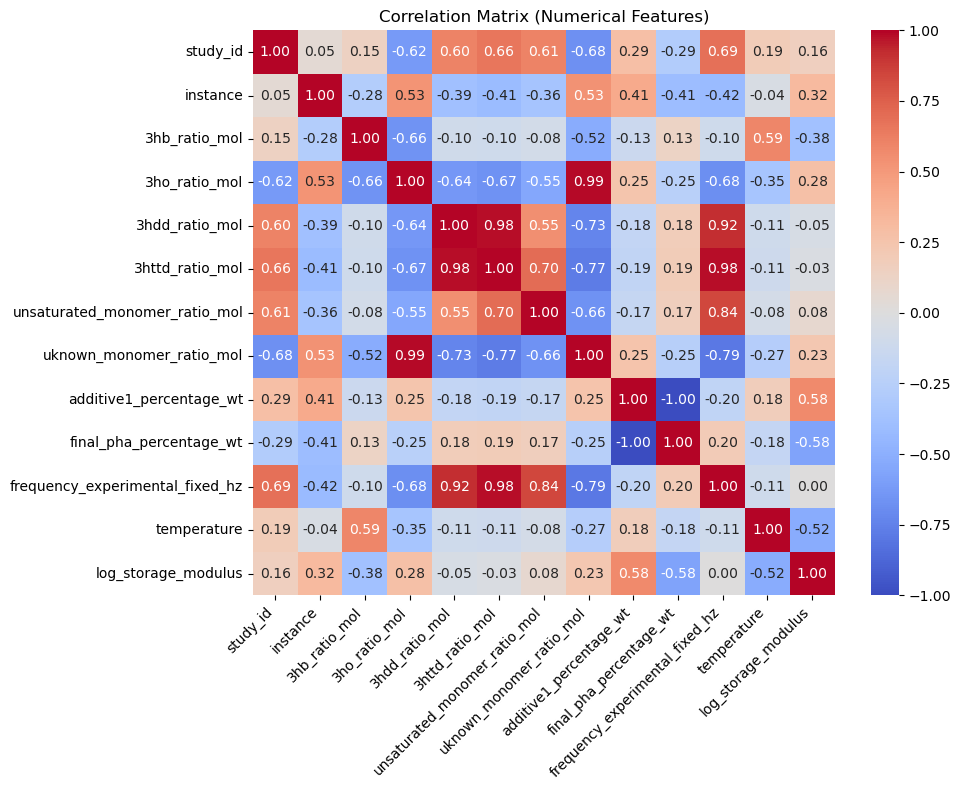

In [81]:
numerical_df = df_final[numerical_cols_lst]

# Compute correlation matrix
corr_matrix = numerical_df.corr() 

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix (Numerical Features)")
plt.xticks(rotation=45, ha="right") 
plt.yticks(rotation=0) 

plt.tight_layout()
# plt.savefig("correlation.tiff", format="tiff", dpi=600, bbox_inches="tight")
plt.show()

## study-aware Train/test splitting

In [82]:
# -----------------------------
# Separate features and target
# -----------------------------
drop_cols = [target, '3httd_ratio_mol', 'uknown_monomer_ratio_mol','frequency_experimental_fixed_hz','3hdd_ratio_mol']

X_train_list, y_train_list = [], []
X_test_list,  y_test_list  = [], []
X_val_list,   y_val_list   = [], []

# -----------------------------
# Per-instance splitting
# -----------------------------
for (study, instance), df_inst in df_final.groupby(['study_id', 'instance']):

    # --- Step 1: validation = highest temperature point(s)
    max_temp = df_inst['temperature'].max()
    df_val_inst = df_inst[df_inst['temperature'] == max_temp]

    X_val_list.append(df_val_inst.drop(columns=drop_cols))
    y_val_list.append(df_val_inst[target])

    # --- Remaining points for train/test
    df_remaining = df_inst[df_inst['temperature'] < max_temp]

    if len(df_remaining) >= 2:
        X_train_inst, X_test_inst, y_train_inst, y_test_inst = train_test_split(
            df_remaining.drop(columns=drop_cols),
            df_remaining[target],
            test_size=0.15,
            random_state=42
        )

    elif len(df_remaining) == 1:
        # Only one point → keep it in train
        X_train_inst = df_remaining.drop(columns=drop_cols)
        y_train_inst = df_remaining[target]

        X_test_inst = pd.DataFrame(columns=X_train_inst.columns)
        y_test_inst = pd.Series(dtype=y_train_inst.dtype)

    else:
        # No remaining points (edge case)
        X_train_inst = pd.DataFrame(columns=df_inst.drop(columns=drop_cols).columns)
        y_train_inst = pd.Series(dtype=df_inst[target].dtype)

        X_test_inst = pd.DataFrame(columns=X_train_inst.columns)
        y_test_inst = pd.Series(dtype=y_train_inst.dtype)

    X_train_list.append(X_train_inst)
    y_train_list.append(y_train_inst)
    X_test_list.append(X_test_inst)
    y_test_list.append(y_test_inst)

# -----------------------------
# Concatenate (DO NOT reset index)
# -----------------------------
X_train = pd.concat(X_train_list)
y_train = pd.concat(y_train_list)

X_test  = pd.concat(X_test_list)
y_test  = pd.concat(y_test_list)

X_val   = pd.concat(X_val_list)
y_val   = pd.concat(y_val_list)

print("Train points:", len(X_train))
print("Test points:", len(X_test))
print("Validation points:", len(X_val))

Train points: 194
Test points: 41
Validation points: 11


## Outlier detection - FAMD + IQR

In [83]:
# Fit FAMD with a reasonably high number of components
famd = FAMD(n_components=30, n_iter=10, random_state=42).fit(X_train)

eigenvalues = famd.eigenvalues_
explained_inertia = eigenvalues / eigenvalues.sum()
cumulative_inertia = np.cumsum(explained_inertia)

famd.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,7.515,24.24%,24.24%
1,4.351,14.04%,38.28%
2,4.002,12.91%,51.19%
3,3.792,12.23%,63.42%
4,2.584,8.33%,71.75%
5,2.103,6.78%,78.54%
6,2.001,6.45%,84.99%
7,2.000,6.45%,91.44%
8,1.363,4.40%,95.84%


In [84]:
# Initial FAMD for outlier detection
n_components_initial = 10
famd2 = FAMD(n_components=n_components_initial, random_state=42)
X_train_famd = famd2.fit_transform(X_train)

X_train_famd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 194 entries, 9 to 232
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       194 non-null    float64
 1   1       194 non-null    float64
 2   2       194 non-null    float64
 3   3       194 non-null    float64
 4   4       194 non-null    float64
 5   5       194 non-null    float64
 6   6       194 non-null    float64
 7   7       194 non-null    float64
 8   8       194 non-null    float64
 9   9       194 non-null    float64
dtypes: float64(10)
memory usage: 16.7 KB


In [85]:
X_train_famd_df = X_train_famd.copy()
X_train_famd_df.columns = [f'Comp{i+1}' for i in range(X_train_famd_df.shape[1])]

X_train_famd_df.tail()

,Comp1,Comp2,Comp3,Comp4,Comp5,Comp6,Comp7,Comp8,Comp9,Comp10
238,4.921096,0.252899,-4.553273,-2.815897,-0.686742,0.274620,-0.024553,-7.686584e-15,-0.701280,-0.175501
233,4.861563,0.112025,-4.539249,-3.022550,-0.618364,0.257686,-0.008419,-5.299604e-15,-0.531633,-0.213396
236,4.897283,0.196550,-4.547664,-2.898558,-0.659391,0.267846,-0.018099,-6.742894e-15,-0.633421,-0.190659
240,4.944909,0.309249,-4.558883,-2.733236,-0.714094,0.281394,-0.031007,-8.685784e-15,-0.769139,-0.160343
232,4.849657,0.083850,-4.536444,-3.063880,-0.604689,0.254299,-0.005192,-4.800004e-15,-0.497703,-0.220975


## Outlier detection with IQR

**Test = 1:** No exclusion
**Test = 2:** +-10 IQR   **Test = 3:** +-7 IQR  

In [86]:
test = 1

# Detect outliers using IQR
def detect_iqr_outliers(df,alpha):
    outlier_indices = set()
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - alpha * IQR
        upper_bound = Q3 + alpha * IQR
        outliers_col = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
        outlier_indices.update(outliers_col)
    return list(outlier_indices)

# Drop outliers
if test == 2:
    alpha = 10
    outlier_idx_train = detect_iqr_outliers(X_train_famd_df, alpha)
    X_train_clean = X_train.drop(index=outlier_idx_train)
    y_train_clean = y_train.drop(index=outlier_idx_train)
    print("IQR outlier detection APPLIED with ±2")

elif test == 3:
    alpha = 7
    outlier_idx_train = detect_iqr_outliers(X_train_famd_df, alpha)
    X_train_clean = X_train.drop(index=outlier_idx_train)
    y_train_clean = y_train_final.drop(index=outlier_idx_train)
    print("IQR outlier detection APPLIED with ±",alpha)

else:
    df_clean = df_final.copy()
    X_train_clean = X_train
    y_train_clean = y_train
    print("IQR outlier detection SKIPPED")

print(f"Original data shape: {X_train.shape}")
print(f"Cleaned data shape: {X_train_clean.shape}")

IQR outlier detection SKIPPED
Original data shape: (194, 9)
Cleaned data shape: (194, 9)


## One-hot encoding

In [87]:
id_cols = ['study_id', 'instance']

X_train_final = X_train_clean.drop(columns=id_cols)
X_test_final  = X_test.drop(columns=id_cols)

numerical_cols_lst = [
    col for col in numerical_cols_lst
    if col not in id_cols
]

categorical_cols_lst = [
    col for col in categorical_cols_lst
    if col not in id_cols
]

In [88]:
X_train = X_train_final.copy()
X_test = X_test_final.copy()

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop=None)
ohe.fit(X_train[categorical_cols_lst])

# Transform
X_train_ohe = ohe.transform(X_train[categorical_cols_lst])
X_test_ohe = ohe.transform(X_test[categorical_cols_lst])

# Convert to DataFrame with proper column names
ohe_columns = ohe.get_feature_names_out(categorical_cols_lst)
X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=ohe_columns, index=X_train.index)
X_test_ohe_df = pd.DataFrame(X_test_ohe, columns=ohe_columns, index=X_test.index)

In [89]:
# combine
X_train_final = pd.concat([X_train.drop(columns=categorical_cols_lst), X_train_ohe_df], axis=1)
X_test_final = pd.concat([X_test.drop(columns=categorical_cols_lst), X_test_ohe_df], axis=1)

print(f"X_train_final shape: {X_train_final.shape}")
print(f"X_test_final shape: {X_test_final.shape}")

X_train_final shape: (194, 8)
X_test_final shape: (41, 8)


## RF and XGBoost regression

In [90]:
# XGBoost
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="rmse",
    n_jobs=-1
)

xgb.fit(X_train_final, y_train_clean)

# Predictions
y_train_pred_xgb = xgb.predict(X_train_final)
y_test_pred_xgb = xgb.predict(X_test_final)


# Random Forest
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_final, y_train_clean)

# Predictions
y_train_pred_rf = rf.predict(X_train_final)
y_test_pred_rf = rf.predict(X_test_final)

In [91]:
y_test = y_test.copy()

def compute_metrics(y_true, y_pred):
    r,_ = pearsonr(y_true, y_pred)
    return {
        'R^2 (log)': r2_score(y_true, y_pred),
        'Pearson r (log)': r,
        'RMSE (log)': root_mean_squared_error(y_true, y_pred),
        'MAE (log)': mean_absolute_error(y_true, y_pred),
#        'RMSE': root_mean_squared_error(10 ** y_true, 10 ** y_pred),
#        'MAE': mean_absolute_error(10 ** y_true, 10 ** y_pred)
    }

metrics = []

# XGBoost
train_xgb = compute_metrics(y_train_clean, y_train_pred_xgb)
test_xgb = compute_metrics(y_test, y_test_pred_xgb)

metrics.append([
    'XGBoost', 'Train',
    train_xgb['R^2 (log)'],
    train_xgb['Pearson r (log)'],
    train_xgb['RMSE (log)'],
    train_xgb['MAE (log)']
#    train_xgb['RMSE'],
 #   train_xgb['MAE']
])

metrics.append([
    'XGBoost', 'Test',
    test_xgb['R^2 (log)'],
    test_xgb['Pearson r (log)'],
    test_xgb['RMSE (log)'],
    test_xgb['MAE (log)']
#    test_xgb['RMSE'],
 #   test_xgb['MAE']
])

# Random Forest
train_rf = compute_metrics(y_train_clean, y_train_pred_rf)
test_rf  = compute_metrics(y_test, y_test_pred_rf)

metrics.append([
    'Random Forest', 'Train',
    train_rf['R^2 (log)'],
    train_rf['Pearson r (log)'],
    train_rf['RMSE (log)'],
    train_rf['MAE (log)']
  #  train_rf['RMSE'],
   # train_rf['MAE']
])

metrics.append([
    'Random Forest', 'Test',
    test_rf['R^2 (log)'],
    test_rf['Pearson r (log)'],
    test_rf['RMSE (log)'],
    test_rf['MAE (log)']
#    test_rf['RMSE'],
 #   test_rf['MAE']
])

In [92]:
metrics_df = pd.DataFrame(
    metrics,
    columns=['Model', 'Dataset', 'R^2 (log)', 'Pearson r (log)', 'RMSE (log)', 'MAE (log)']
)

print(metrics_df)

           Model Dataset  R^2 (log)  Pearson r (log)  RMSE (log)  MAE (log)
0        XGBoost   Train   0.956419         0.977967    0.245387   0.094827
1        XGBoost    Test   0.794750         0.894716    0.571434   0.275409
2  Random Forest   Train   0.950641         0.975128    0.261147   0.123171
3  Random Forest    Test   0.854994         0.924760    0.480305   0.236588


## Grid search - RF

In [93]:
# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [10, 20, 30],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]
}

folds = 5
cv = KFold(n_splits=folds, shuffle=True, random_state=42)

# Initialize the Grid Search with Random Forest
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=cv, scoring='r2', n_jobs=1, verbose=2)

# Fit
grid_search.fit(X_train_final, y_train_clean)

# Extract the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

# Print
print(f"Best parameters found: {best_params}")
print(f"Best R^2 score from Grid Search (CV): {best_score}")

# Use the best estimator
best_rf = grid_search.best_estimator_

# Predictions
y_train_pred_grid = best_rf.predict(X_train_final)
y_test_pred_grid = best_rf.predict(X_test_final)

# Metrics
r2_train_grid = r2_score(y_train_clean, y_train_pred_grid)
r2_test_grid = r2_score(y_test, y_test_pred_grid)

# Pearson r
pearson_r_train, _ = pearsonr(y_train_clean, y_train_pred_grid)
pearson_r_test, _ = pearsonr(y_test, y_test_pred_grid)

# Cross-Validation R^2 Score with the best model
cv_scores_r2_grid = cross_val_score(best_rf, X_train_final, y_train_clean, cv=cv, scoring='r2')
mean_cv_r2_grid = np.mean(cv_scores_r2_grid)
std_cv_r2_grid = np.std(cv_scores_r2_grid)

# Print the R^2 scores
summary_df = pd.DataFrame({
    'Metric': ['Train R^2', 'Test R^2', 'CV Mean R^2', 'CV SD R^2', 'Train Pearson r', 'Test Pearson r'],
    'RF (Tuned)': [
        r2_train_grid,
        r2_test_grid,
        mean_cv_r2_grid,
        std_cv_r2_grid,
        pearson_r_train,
        pearson_r_test
    ]
})

print(summary_df)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=10, min_samples

## Plot results

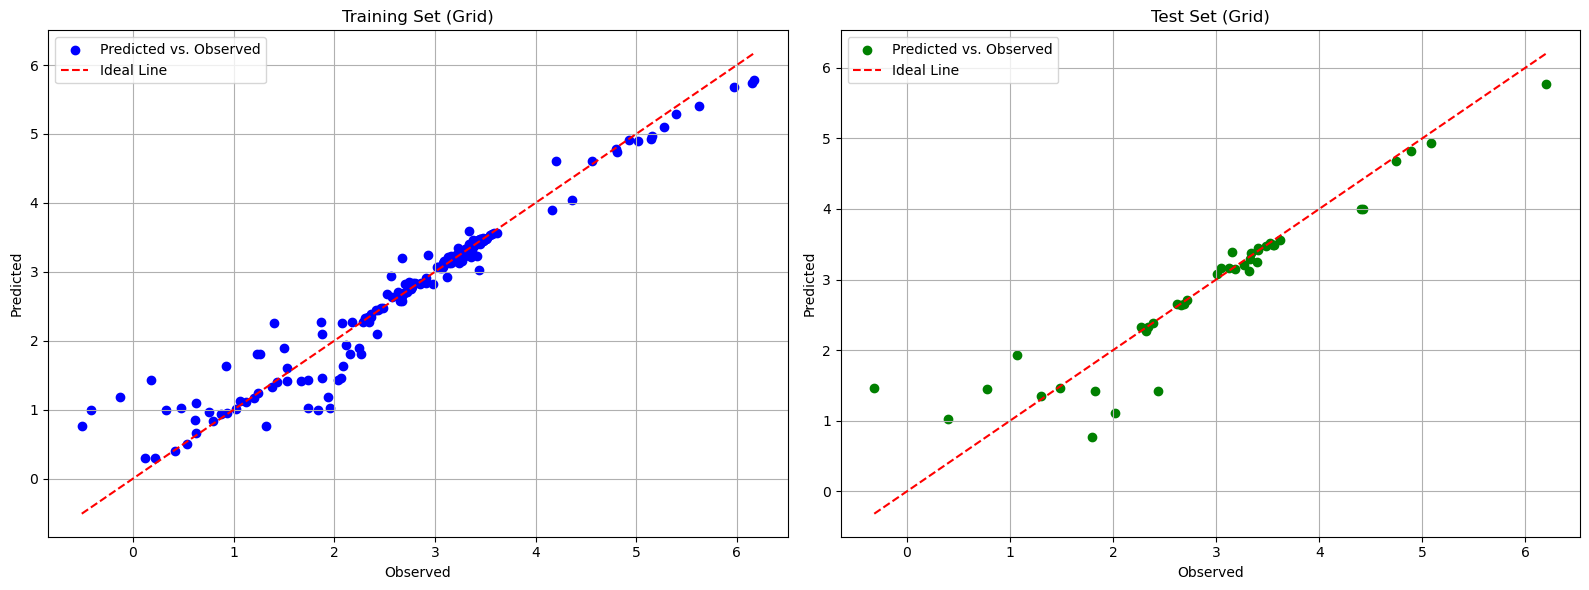

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # width doubled for 2 plots

# Plot Training Set
axes[0].scatter(y_train_clean, y_train_pred_grid, color='blue', label='Predicted vs. Observed')
axes[0].plot([min(y_train_clean), max(y_train_clean)],
             [min(y_train_clean), max(y_train_clean)],
             linestyle='--', color='red', label='Ideal Line')
axes[0].set_xlabel('Observed')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Training Set (Grid)')
axes[0].legend()
axes[0].grid(True)

# Plot Test Set
axes[1].scatter(y_test, y_test_pred_grid, color='green', label='Predicted vs. Observed')
axes[1].plot([min(y_test), max(y_test)],
             [min(y_test), max(y_test)],
             linestyle='--', color='red', label='Ideal Line')
axes[1].set_xlabel('Observed')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Test Set (Grid)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("mcl_dts_storage_rf_pair_grid.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Plot RMSE w.r.t No of trees

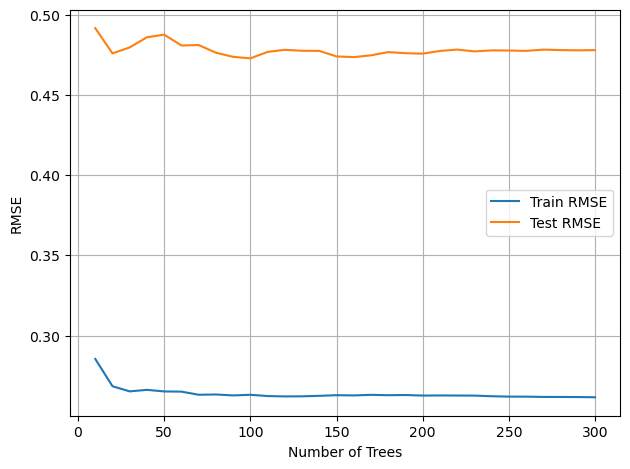

In [95]:
train_rmse = []
test_rmse = []

n_estimators_range = range(10, 301, 10)

for n in n_estimators_range:
    rf = RandomForestRegressor(
        n_estimators=n,
        max_depth=best_params['max_depth'],
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_final, y_train_clean)

    y_train_pred = rf.predict(X_train_final)
    y_test_pred = rf.predict(X_test_final)

    train_rmse.append(root_mean_squared_error(y_train_clean, y_train_pred))
    test_rmse.append(root_mean_squared_error(y_test, y_test_pred))

plt.figure()
plt.plot(n_estimators_range, train_rmse, label="Train RMSE")
plt.plot(n_estimators_range, test_rmse, label="Test RMSE")
plt.xlabel("Number of Trees")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("mcl_dts_storage_rmse.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Feature importance

In [96]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_final)     # array shape: (n_samples, n_features)
base_value = explainer.expected_value

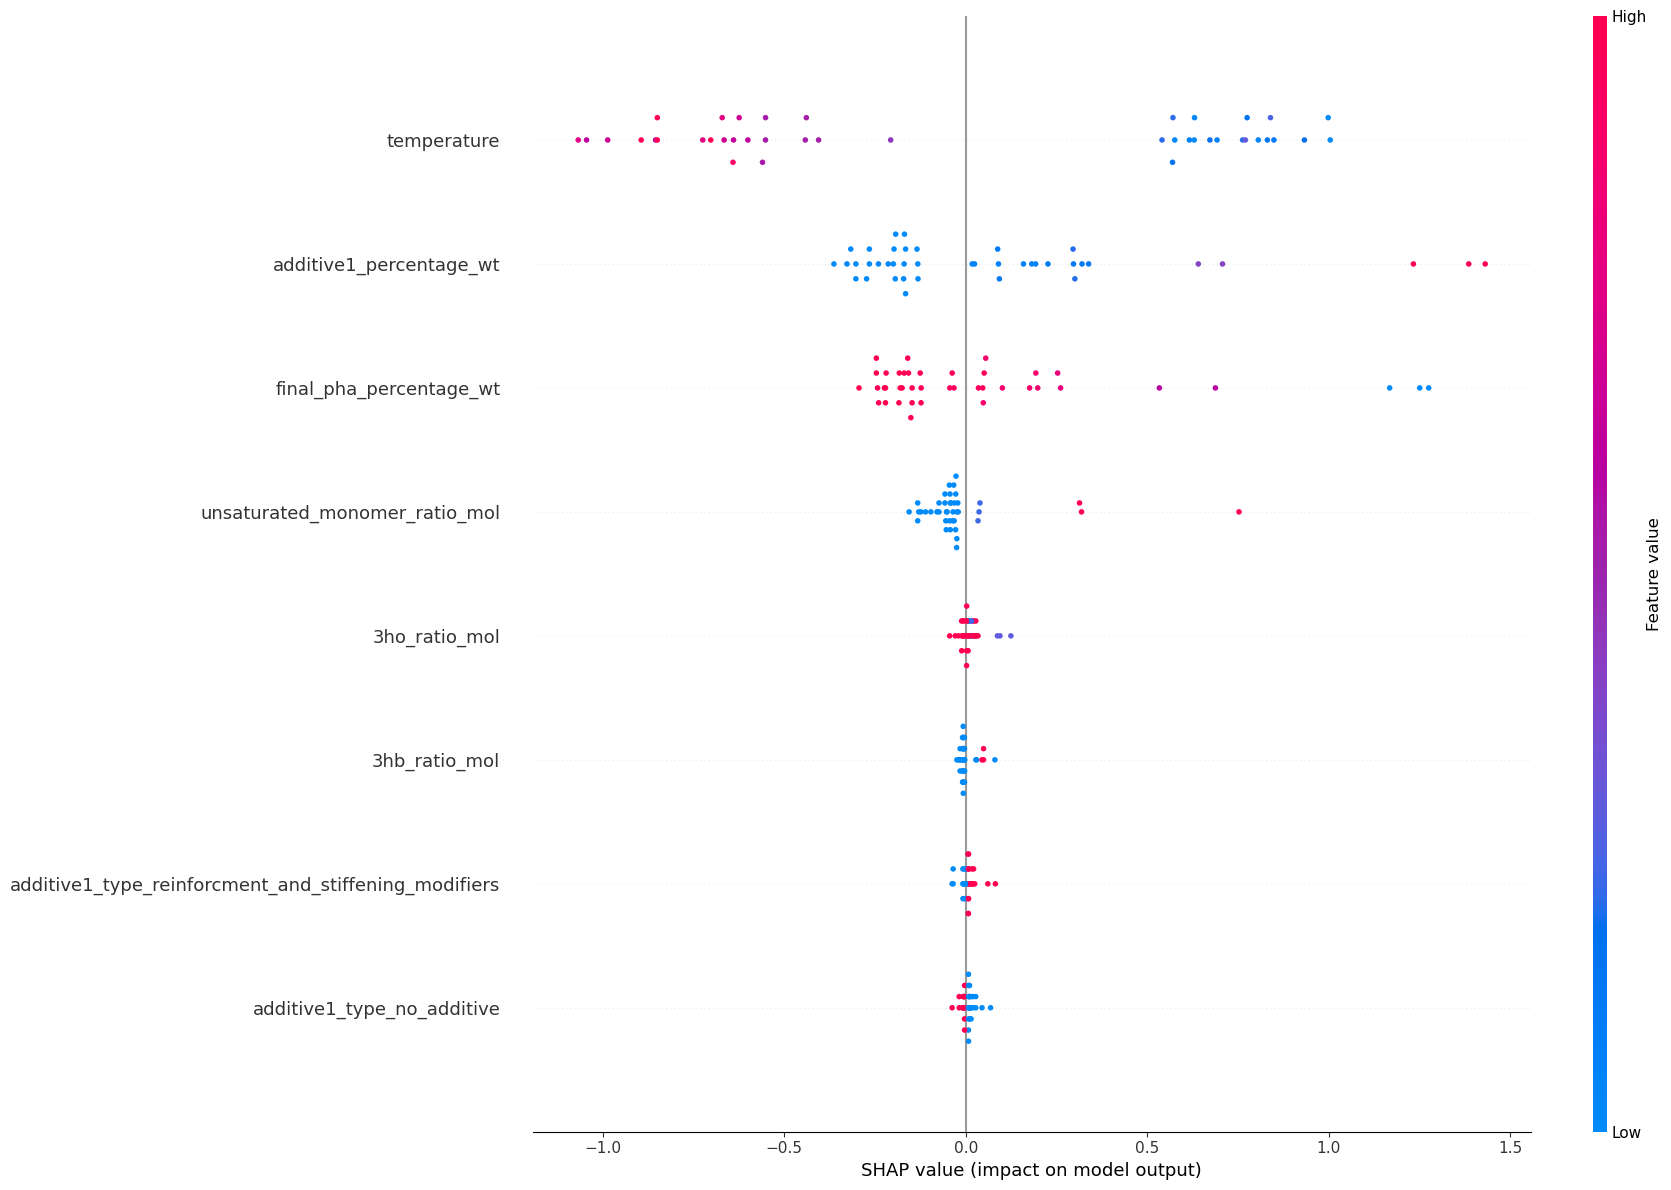

In [97]:
shap.summary_plot(
    shap_values,
    X_test_final,
#    max_display=10,        # <-- top 10 features only
    show=False,
    plot_size=(18, 12)
)

plt.tight_layout()
plt.savefig("mcl_dts_storage_rf_shap.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Grid search - XGBoost

In [98]:
# Define the parameter grid
param_grid = {
     'n_estimators': [200, 400, 800],
    'learning_rate': [0.05, 0.01],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8]
}

folds = 5
cv = KFold(n_splits=folds, shuffle=True, random_state=42)

# Initialize the Grid Search with Random Forest
grid_search2 = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=cv, scoring='r2', n_jobs=1, verbose=2)

# Fit
grid_search2.fit(X_train_final, y_train_clean)

# Extract the best parameters
best_params2 = grid_search2.best_params_
best_score2 = grid_search2.best_score_

# Print
print(f"Best parameters found: {best_params2}")
print(f"Best R^2 score from Grid Search (CV): {best_score2}")

# Use the best estimator
best_xgb = grid_search2.best_estimator_

# predictions
y_train_pred_grid2 = best_xgb.predict(X_train_final)
y_test_pred_grid2 = best_xgb.predict(X_test_final)

# Metrics
r2_train_grid2 = r2_score(y_train_clean, y_train_pred_grid2)
r2_test_grid2 = r2_score(y_test, y_test_pred_grid2)

# Pearson r
pearson_r_train2, _ = pearsonr(y_train_clean, y_train_pred_grid2)
pearson_r_test2, _ = pearsonr(y_test, y_test_pred_grid2)

# Cross-Validation R^2 Score with the best model
cv_scores_r2_grid2 = cross_val_score(best_xgb, X_train_final, y_train_clean, cv=cv, scoring='r2')
mean_cv_r2_grid2 = np.mean(cv_scores_r2_grid2)
std_cv_r2_grid2 = np.std(cv_scores_r2_grid2)

# Print the R^2 scores
summary_df2 = pd.DataFrame({
    'Metric': ['Train R^2', 'Test R^2', 'CV Mean R^2', 'CV SD R^2', 'Train Pearson r', 'Test Pearson r'],
    'XGBoost (Tuned)': [
        r2_train_grid2,
        r2_test_grid2,
        mean_cv_r2_grid2,
        std_cv_r2_grid2,
        pearson_r_train2,
        pearson_r_test2
    ]
})

print(summary_df2)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.7; total time=   0.2s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.7; total time=   0.2s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.7; total time=   0.2s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.7; total time=   0.2s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.7; total time=   0.2s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.8; total time=   0.2s
[CV] END 

## Plot results

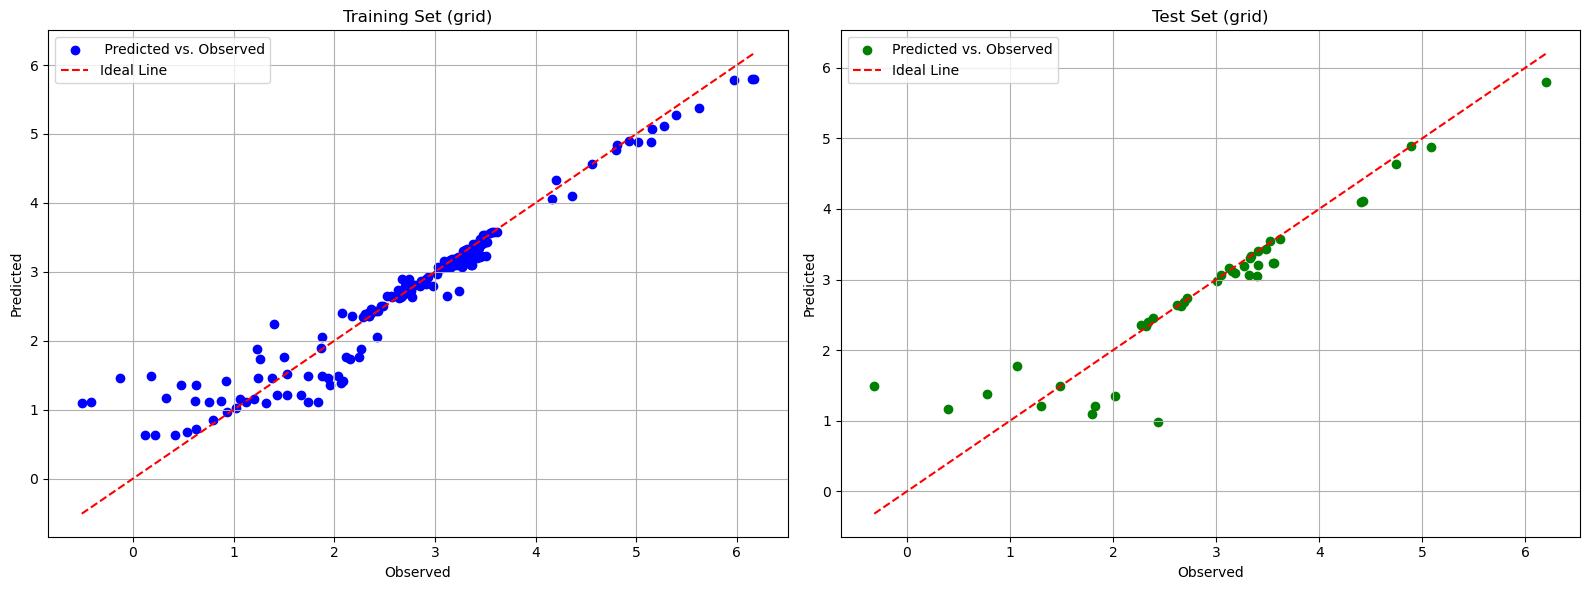

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # width doubled for 2 plots

# Plot Training Set
axes[0].scatter(y_train_clean, y_train_pred_grid2, color='blue', label=' Predicted vs. Observed')
axes[0].plot([min(y_train_clean), max(y_train_clean)],
             [min(y_train_clean), max(y_train_clean)],
             linestyle='--', color='red', label='Ideal Line')
axes[0].set_xlabel('Observed')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Training Set (grid)')
axes[0].legend()
axes[0].grid(True)

# Plot Test Set
axes[1].scatter(y_test, y_test_pred_grid2, color='green', label='Predicted vs. Observed')
axes[1].plot([min(y_test), max(y_test)],
             [min(y_test), max(y_test)],
             linestyle='--', color='red', label='Ideal Line')
axes[1].set_xlabel('Observed')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Test Set (grid)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("mcl_dts_storage_xgb_pair_grid.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Loss plot

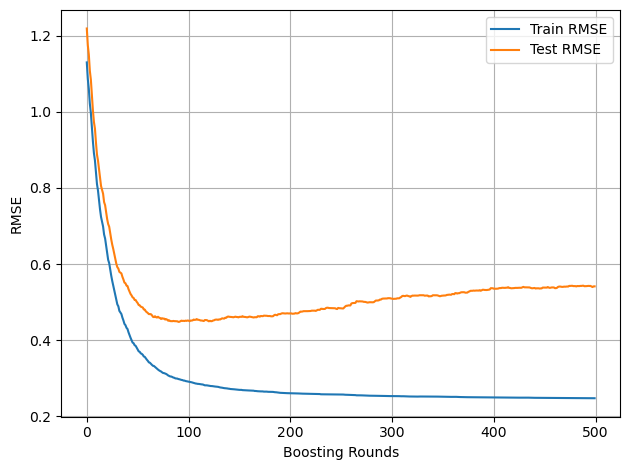

In [100]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=best_params2['max_depth'],
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric=["rmse"],
    random_state=42
)

model.fit(
    X_train_final, y_train_clean,
    eval_set=[(X_train_final, y_train_clean), (X_test_final, y_test)],
    verbose=False
)

results = model.evals_result()

epochs = len(results['validation_0']['rmse'])

plt.figure()
plt.plot(range(epochs), results['validation_0']['rmse'], label="Train RMSE")
plt.plot(range(epochs), results['validation_1']['rmse'], label="Test RMSE")
plt.xlabel("Boosting Rounds")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("mcl_dts_storage_xgb_loss.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Feature importance

In [101]:
explainer2 = shap.TreeExplainer(best_xgb)
shap_values2 = explainer2.shap_values(X_test_final)     # array shape: (n_samples, n_features)
base_value2 = explainer2.expected_value

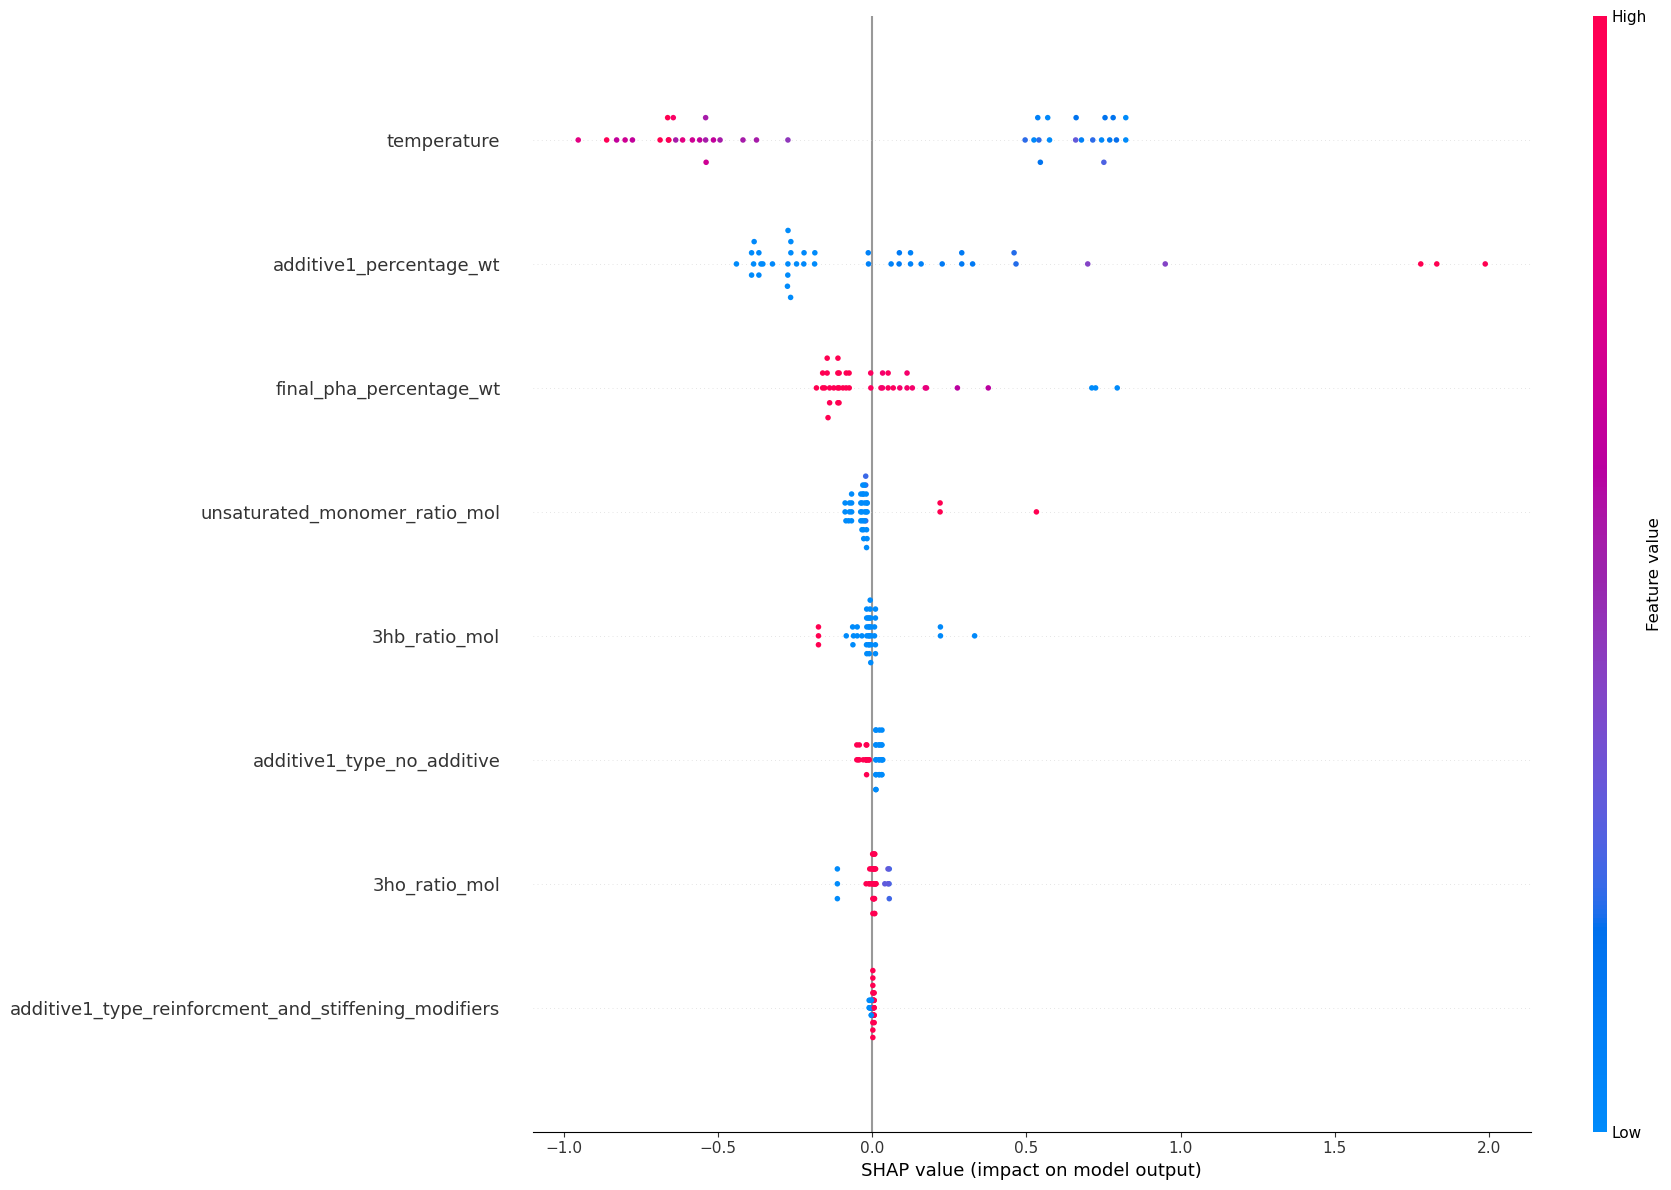

In [102]:
shap.summary_plot(
    shap_values2,
    X_test_final,
#    max_display=10,        # <-- top 10 features only
    show=False,
    plot_size=(18, 12)
)

plt.tight_layout()
plt.savefig("mcl_dts_storage_xgb_shap.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Validation check on unseen data (excl. full instances)

In [103]:
X_val.columns

Index(['study_id', 'instance', '3hb_ratio_mol', '3ho_ratio_mol',
       'unsaturated_monomer_ratio_mol', 'additive1_percentage_wt',
       'final_pha_percentage_wt', 'additive1_type', 'temperature'],
      dtype='object')

In [104]:
X_val  = X_val.drop(columns=id_cols)

In [105]:
X_val_ohe = ohe.transform(X_val[categorical_cols_lst])
X_val_ohe_df = pd.DataFrame(X_val_ohe, columns=ohe_columns, index=X_val.index)
X_val_final = pd.concat([X_val.drop(columns=categorical_cols_lst), X_val_ohe_df], axis=1)

In [106]:
cols = X_val_final.columns.tolist()
first_col = cols.pop(0)

# Insert it at index 2 (third position)
cols.insert(2, first_col)
# X_val_final = X_val_final[cols]
# y_val = df_val[target]

# RF
y_val_pred_rf = best_rf.predict(X_val_final)
r_rf,_ = pearsonr(y_val, y_val_pred_rf)
print(f'Pearson on unseen set (RF): {r_rf}')

# XGBoost
y_val_pred_xg = best_xgb.predict(X_val_final)
r_xg,_ = pearsonr(y_val, y_val_pred_xg)
print(f'Pearson on unseen set (XGB): {r_xg}')

Pearson on unseen set (RF): 0.769427298248917
Pearson on unseen set (XGB): 0.8087405015299662


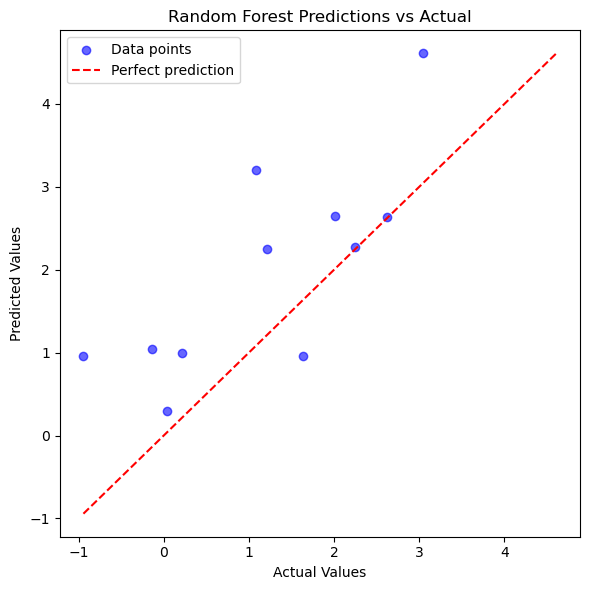

In [107]:
# Scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_val_pred_rf, color='blue', alpha=0.6, label='Data points')

# Perfect prediction line
min_val = min(y_val.min(), y_val_pred_rf.min())
max_val = max(y_val.max(), y_val_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect prediction')

# Add labels and title if needed
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Random Forest Predictions vs Actual')
plt.legend()

plt.tight_layout()
plt.savefig("mcl_dts_storage_rf_unseen.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

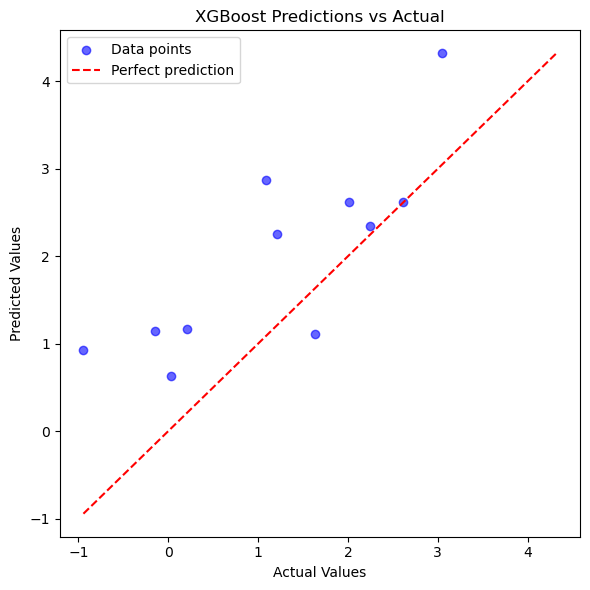

In [108]:
## Scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_val_pred_xg, color='blue', alpha=0.6, label='Data points')

# Perfect prediction line
min_val = min(y_val.min(), y_val_pred_xg.min())
max_val = max(y_val.max(), y_val_pred_xg.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect prediction')

# Add labels and title if needed
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('XGBoost Predictions vs Actual')
plt.legend()

plt.tight_layout()
plt.savefig("mcl_dts_storage_xg_unseen.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Jaqpot

In [109]:
df_stor.columns

Index(['study_id', 'instance', '3hb_ratio_mol', '3ho_ratio_mol',
       '3hdd_ratio_mol', '3httd_ratio_mol', 'unsaturated_monomer_ratio_mol',
       'uknown_monomer_ratio_mol', 'additive1_percentage_wt', 'additive1_type',
       'final_pha_percentage_wt', 'frequency_experimental_fixed_hz',
       'temperature', 'storage_modulus', 'log_storage_modulus'],
      dtype='object')

In [112]:
features = [
    'unsaturated_monomer_ratio_mol',
    '3hb_ratio_mol',
    '3ho_ratio_mol',
    'final_pha_percentage_wt',
    'additive1_type',
    'additive1_percentage_wt',
#    'frequency_experimental_fixed_hz',
    'temperature'
]

target = 'storage_modulus'

measure_unit = 'MPa'

In [113]:
# Create DataFrame
df_new = df_stor[features + [target]]

# Drop rows with N/A value
mask = (
    df_new[target].notna() &
    df_new[features].notna().all(axis=1)
)

# Create final dataset
df_final = df_new.loc[mask, features + [target]].copy()
df_final[target] = np.log10(df_final[target])  # log-transform
df_final.columns = df_final.columns.str.replace(' ', '_', regex=False)

In [115]:
df_final = df_final.rename(columns={
    '3hb_ratio_mol': 'ratio_3hb_mol',
    '3ho_ratio_mol': 'ratio_3ho_mol'
})

df_final.columns

Index(['unsaturated_monomer_ratio_mol', 'ratio_3hb_mol', 'ratio_3ho_mol',
       'final_pha_percentage_wt', 'additive1_type', 'additive1_percentage_wt',
       'temperature', 'storage_modulus'],
      dtype='object')

In [117]:
df_final['unsaturated_monomer_ratio_mol'] = (
    df_final['unsaturated_monomer_ratio_mol'].astype(float)
)

df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246 entries, 0 to 245
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   unsaturated_monomer_ratio_mol  246 non-null    float64
 1   ratio_3hb_mol                  246 non-null    float64
 2   ratio_3ho_mol                  246 non-null    float64
 3   final_pha_percentage_wt        246 non-null    float64
 4   additive1_type                 246 non-null    object 
 5   additive1_percentage_wt        246 non-null    float64
 6   temperature                    246 non-null    float64
 7   storage_modulus                246 non-null    float64
dtypes: float64(7), object(1)
memory usage: 17.3+ KB


In [118]:
# Separate features and target
drop_cols = [target]

X = df_final.drop(columns=drop_cols)
y = df_final[target]

In [119]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42
)

print('Train set size:', X_train.shape, '\n Test set size',X_test.shape)

Train set size: (209, 7) 
 Test set size (37, 7)


In [120]:
numerical_cols_lst = (
    df_final
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

categorical_cols_lst = (
    df_final
    .select_dtypes(include=['object', 'category'])
    .columns
    .tolist()
)

In [121]:
numerical_cols_lst.remove(target)
features_num = numerical_cols_lst
features_cat = categorical_cols_lst

In [122]:
df_train = X_train.copy()
df_train[target] = y_train

train_dataset = JaqpotTabularDataset(
    df=df_train,
    x_cols=X_train.columns.to_list(),
    y_cols=target,
    task="REGRESSION",
)

df_test = X_test.copy()
df_test[target] = y_test

test_dataset = JaqpotTabularDataset(
    df=df_test,
    x_cols=X_test.columns.to_list(),
    y_cols=target,
    task="REGRESSION",
)

In [123]:
preprocessing = ColumnTransformer(
    transformers=[
        ('numerical_features', StandardScaler(), features_num),
        ('categorical_features', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary'), features_cat)
    ],
    remainder='drop',
)

In [129]:
model = XGBRegressor(
    random_state=42,
    n_estimators=400,
    learning_rate=0.01,
    max_depth=4,
    subsample=1,
    colsample_bytree=0.9,
#    min_child_weight=5,
 #   reg_lambda=5,
)

jaqpot_model = XGBoostModel(
    dataset=train_dataset,
    model=model,
    doa=[Leverage(), BoundingBox()],
    preprocess_x=preprocessing,
)
jaqpot_model.random_seed = 1231
jaqpot_model.fit()

Goodness-of-fit metrics on training set:
{'r2': 0.9412112722318446, 'mae': 0.16244127959216642, 'rmse': 0.30015654873021286}


In [130]:
from sklearn.base import clone

# Manually create what fit() should have set
jaqpot_model.unfit_pipeline = clone(jaqpot_model.pipeline)

# Now this should work
jaqpot_model.cross_validate(train_dataset, n_splits=10)

{'r2': 0.8708746288821084,
 'mae': 0.23450049761783368,
 'rmse': 0.3976017158147903}

In [131]:
# Evaluate the model on the test dataset
jaqpot_model.evaluate(test_dataset)

{'r2': 0.8013901849760701,
 'mae': 0.321276665193836,
 'rmse': 0.5530450972622917}

In [132]:
# Conducts a randomization test to assess the model's robustness
jaqpot_model.randomization_test(
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    n_iters=10,
)

{'iteration_0': {'Train': {'r2': 0.3377733040020985,
   'mae': 0.7476825177111289,
   'rmse': 1.00740507487994},
  'Test': {'r2': -0.015804082791968987,
   'mae': 0.9171120687778358,
   'rmse': 1.2507346172787976}},
 'iteration_1': {'Train': {'r2': 0.23827058197823137,
   'mae': 0.798293826775769,
   'rmse': 1.080441249232274},
  'Test': {'r2': -0.22198870109085678,
   'mae': 1.0619097556382742,
   'rmse': 1.3718094439556425}},
 'iteration_2': {'Train': {'r2': 0.37456118304920627,
   'mae': 0.736680556266986,
   'rmse': 0.9790237062012411},
  'Test': {'r2': -0.42789283111998366,
   'mae': 1.1868120874802326,
   'rmse': 1.4828868016775374}},
 'iteration_3': {'Train': {'r2': 0.2819073317695441,
   'mae': 0.7730195657101687,
   'rmse': 1.0490375610167413},
  'Test': {'r2': -0.03563334941316687,
   'mae': 0.9749891667583775,
   'rmse': 1.2628832606146527}},
 'iteration_4': {'Train': {'r2': 0.36522731756861104,
   'mae': 0.6943891059897992,
   'rmse': 0.9863019833816176},
  'Test': {'r2': -

In [133]:
doa_predictions = jaqpot_model.predict_doa(test_dataset)
print(doa_predictions)

{'LEVERAGE': [{'h': 0.013701517846914344, 'hStar': 0.11483253588516747, 'inDoa': True}, {'h': 0.008416718837182695, 'hStar': 0.11483253588516747, 'inDoa': True}, {'h': 0.10892378776791664, 'hStar': 0.11483253588516747, 'inDoa': True}, {'h': 0.01034726166192864, 'hStar': 0.11483253588516747, 'inDoa': True}, {'h': 0.06643960745593963, 'hStar': 0.11483253588516747, 'inDoa': True}, {'h': 0.08734243846137335, 'hStar': 0.11483253588516747, 'inDoa': True}, {'h': 0.008995546100975678, 'hStar': 0.11483253588516747, 'inDoa': True}, {'h': 0.013886324714117491, 'hStar': 0.11483253588516747, 'inDoa': True}, {'h': 0.006753361252785176, 'hStar': 0.11483253588516747, 'inDoa': True}, {'h': 0.06636875996614802, 'hStar': 0.11483253588516747, 'inDoa': True}, {'h': 0.06985805486581553, 'hStar': 0.11483253588516747, 'inDoa': True}, {'h': 0.08644384103234798, 'hStar': 0.11483253588516747, 'inDoa': True}, {'h': 0.0657050663101211, 'hStar': 0.11483253588516747, 'inDoa': True}, {'h': 0.07652481308652906, 'hStar

In [134]:
summary = {}
for key in ['LEVERAGE','BOUNDING_BOX']:
    df_doa = pd.DataFrame(doa_predictions[key])
    summary[key] = {
        'n_total': len(df_doa),
        'n_in': int(df_doa['inDoa'].sum()),
        'n_out': int((~df_doa['inDoa']).sum())
    }
summary

{'LEVERAGE': {'n_total': 37, 'n_in': 37, 'n_out': 0},
 'BOUNDING_BOX': {'n_total': 37, 'n_in': 37, 'n_out': 0}}

In [135]:
# Upload the pretrained model on Jaqpot
jaqpot = Jaqpot()
jaqpot.login()
jaqpot_model.deploy_on_jaqpot(
    jaqpot=jaqpot,
    name="Storage modulus regression model for mcl-PHAs A.N.I.P.H.",
    description="Prediction of log-transformed storage modulus for mcl-PHAs using Dynamic Temperature Sweep (DTS) data. To convert to actual storage modulus: modulus = 10^(predicted value).",
    visibility="PUBLIC",
)

Open this URL in your browser and log in:
https://login.jaqpot.org/realms/jaqpot/protocol/openid-connect/auth?client_id=jaqpot-client&response_type=code&redirect_uri=urn:ietf:wg:oauth:2.0:oob&scope=openid email profile&state=random_state_value&nonce=


Enter the authorization code you received:  ········


  2026-07-10 01:39:13,965 - INFO - Model has been successfully uploaded. The url of the model is https://app.jaqpot.org/dashboard/models/2394


In [136]:
df_final[features_num].agg(['min','max'])

,unsaturated_monomer_ratio_mol,ratio_3hb_mol,ratio_3ho_mol,final_pha_percentage_wt,additive1_percentage_wt,temperature
min,0.0,0.0,0.0,50.0,0.0,-125.0
max,49.0,72.9,86.0,100.0,50.0,180.0
